# Sistemas de Recomendación - Tu Futuro según la Data
Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

En base a los resultados del modelo, los estudiantes deberán desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.

## 1. Lectura del data y eliminación duplicados.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
from surprise.model_selection import train_test_split
from surprise import Reader, Dataset  # Lectura y carga del dataset
from surprise import SVD  # Modelo: Singular Value Decomposition
from surprise import accuracy  # Métricas

#Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import math

#warnings
import warnings
warnings.filterwarnings("ignore")

# To save models
import json
import pickle

In [3]:
df_ini = pd.read_csv('../data/raw/13 adult-census-income.csv', sep=',')
df_ini.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


#### Variables definidas
- age: Edad de la persona. Numérico
- workclass: Categoría laboral (Privado, Gobierno, Autoempleado, etc.). Categórico
- fnlwgt: Peso final (estimación de personas con características parecidas a la del individuo). Numérico
- education: Máximo nivel educativo alcanzado (Bachillerato, Licenciatura, etc.). Categórico
- education.num: El mismo nivel educativo convertido a un número (ej: 9 = HS-grad). Numérico
- marital.status: Estado civil actual (Casado, Divorciado, Viudo, etc.). Categórico
- occupation: Tipo de trabajo o profesión que desempeña. Categórico
- relationship: Parentesco o rol dentro del núcleo familiar (Esposo, Hijo, etc.). Categórico
- race: Raza o etnia de la persona. Categórico
- sex: Género de la persona. Categórico
- capital.gain: Ganancias obtenidas por inversiones o ventas de activos. Numérico
- capital.loss: Pérdidas financieras por inversiones o ventas de activos. Numérico
- hours.per.week: Cantidad de horas que la persona trabaja a la semana. Numérico
- native.country: País de origen. Categórico
- income: Variable Objetivo: Si la persona gana más o menos de $50,000 anuales. Categórico

In [4]:
df_ini.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

In [5]:
df_ini.shape

(32561, 15)

In [6]:
# Elimino los duplicados creando un df nuevo.
df = df_ini.drop_duplicates()
df = df.reset_index(inplace=False, drop=True)
df.shape

(32537, 15)

## 2. Preprocesamiento de datos. EDA
Haz la limpieza de datos nulos o mal codificados, la transformación de variables categóricas, normaliza las variables numéricas.


In [7]:
# Compruebo columna por columna donde tengo datos con ? para luego cambiarlos.
df['occupation'].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
?                    1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [8]:
# Reemplazo los valores "?" por valores nulos.
df.replace("?", pd.NA, inplace=True)

# Elimino filas con valores nulos
df.dropna(inplace=True)

df.shape

(30139, 15)

In [9]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [10]:
# Elimino las dos columnas con las que no quiero trabajar. Ya que con 'education.num' estamos teniendo el mismo resultado que con education y tanto capital.gain, como capital loss,
# no nos ayuda determinar que tiene que hacer una persona para ganar más dinero, que es lo que buscamos en este proyecto.

df = df.drop(['education', 'fnlwgt', 'capital.gain', 'capital.loss'], axis=1)

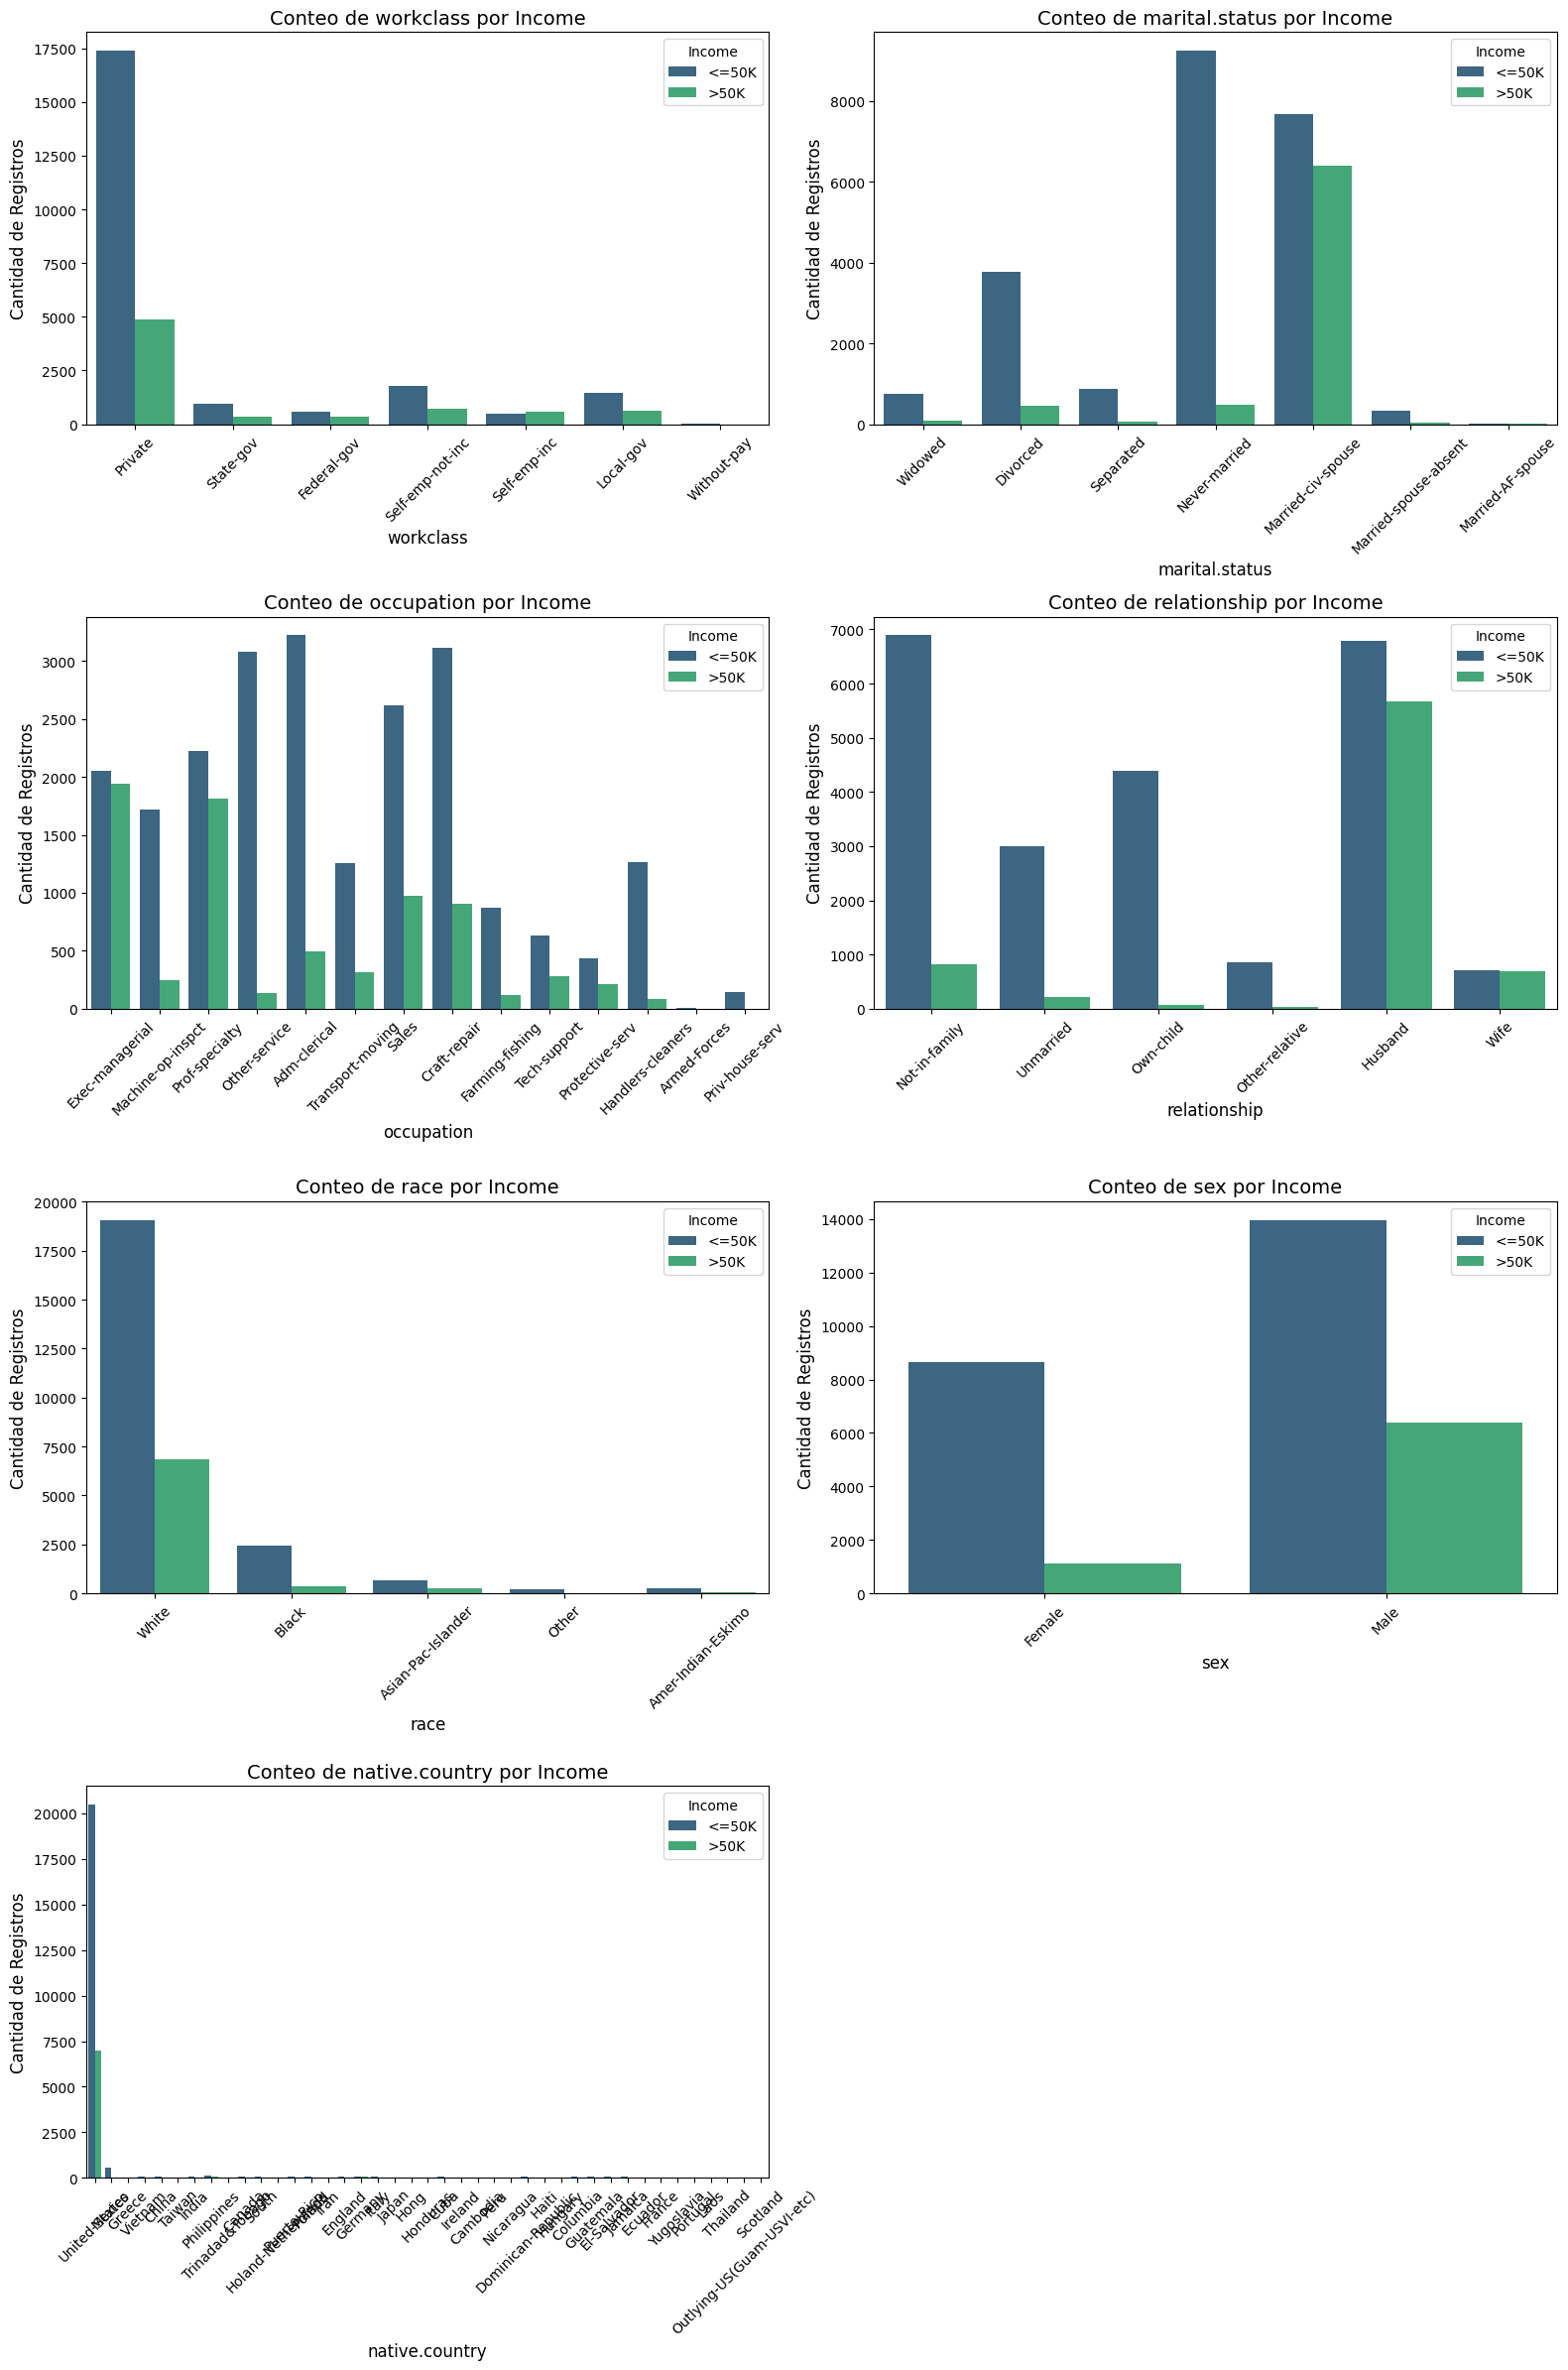

In [11]:
# Gráfico de Variables categoricas.

# Variables categóricas
num_colum = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

# Configuración de la cuadrícula
cols_grid = 2
rows_grid = math.ceil(len(num_colum) / cols_grid)

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 6))
axes = axes.flatten()

for i, col in enumerate(num_colum):
    # Usamos countplot para contar frecuencias
    sns.countplot(data=df, x=col, hue='income', ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Conteo de {col} por Income', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Cantidad de Registros', fontsize=12)
    axes[i].legend(title='Income', loc='upper right')
    
    # Rotar etiquetas X para que sean legibles
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar el último gráfico vacío (ya que son 7 variables en una cuadrícula de 8)
if len(axes) > len(num_colum):
    for j in range(len(num_colum), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

>### Observaciones:
>
>En el análisis de datos categóricos vemos a simple vista que la mayoría de personas tienen un ingreso anual inferior o igual a 50k, a parte podemos observar que:
>- La clase trabajadora privada que es la mayoría de los registros ganan menos de 50k al año.
>- Casi la mitad de los registros como casados tienen unos ingresos superiores a 50k.
>- Las ocupaciones de "Exec-managerial" y "Prof-specialty" son los que más ganan anualmente.
>- La raza blanca gana más anualmente que el resto de razas, también es que hay más registros. 
>- Los hombres ganan más que las mujeres.


In [12]:
df.dtypes

age                int64
workclass         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
hours.per.week     int64
native.country    object
income            object
dtype: object

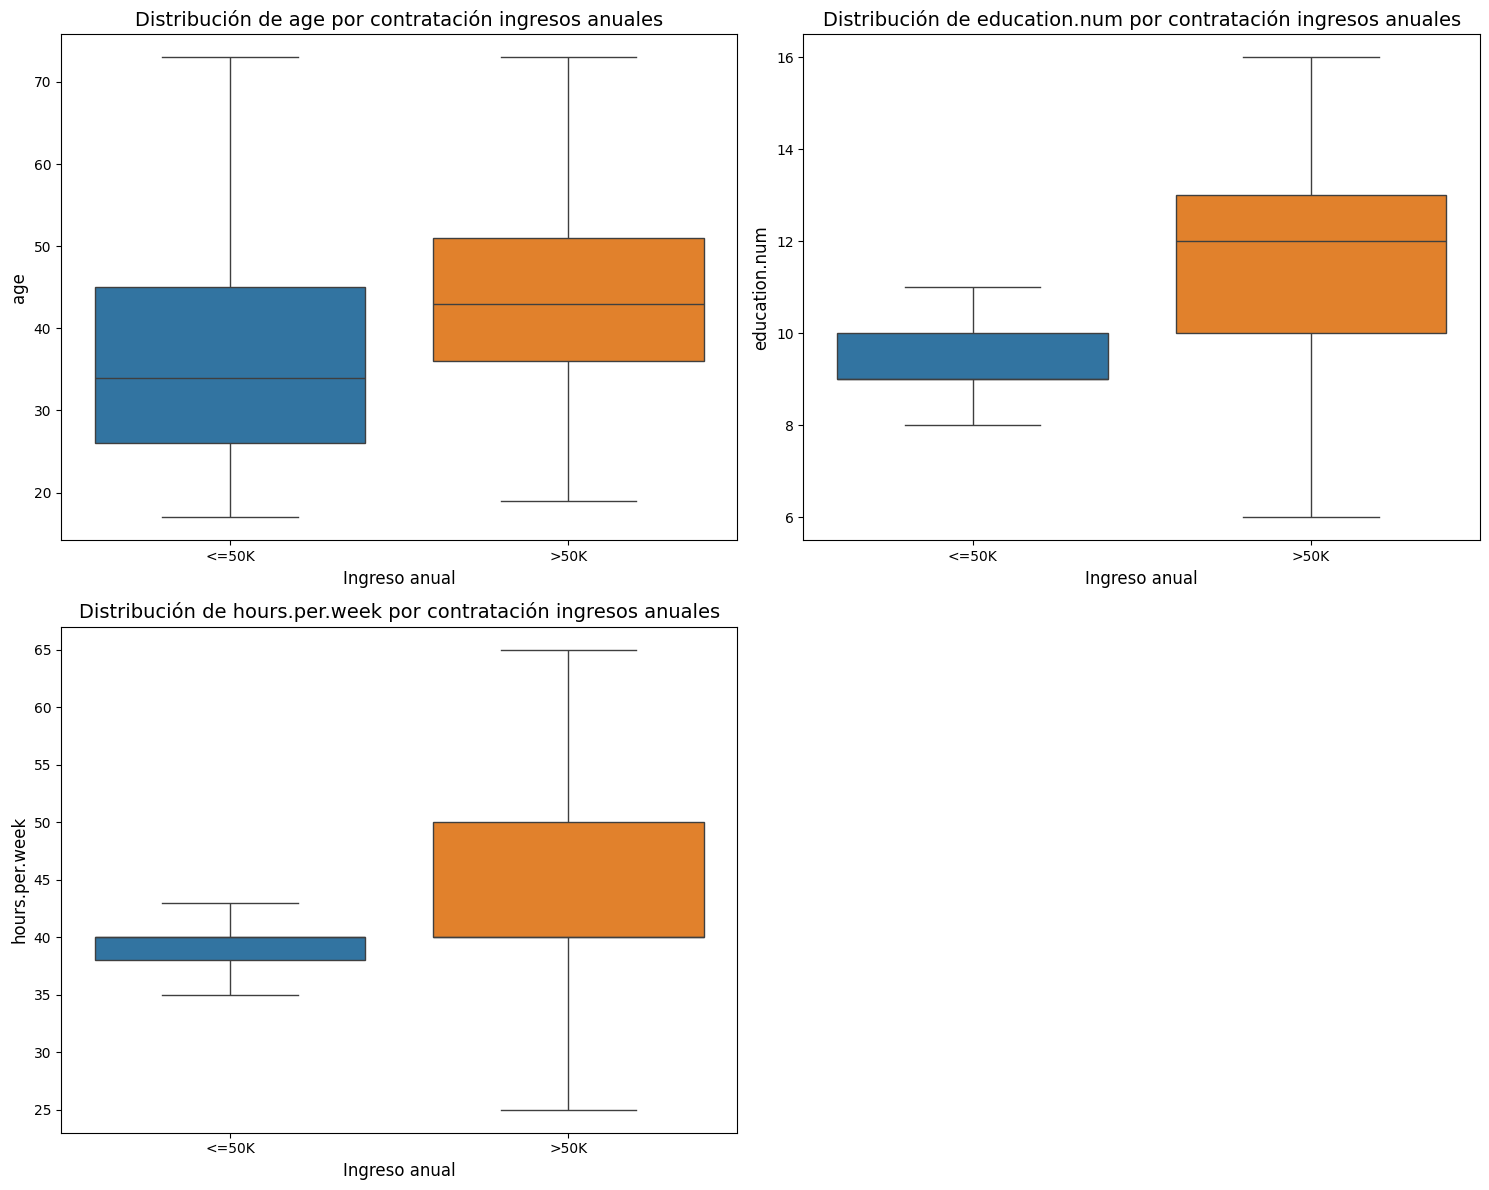

In [13]:
# Gráfico de Variables numéricas.

num_colum = ['age', 'education.num','hours.per.week']
n_columnas = 2
n_filas = math.ceil(len(num_colum) / n_columnas)

fig, axes = plt.subplots(n_filas, n_columnas,figsize=(15, 6 * n_filas))

axes = axes.flatten()

for i, col in enumerate(num_colum):
    sns.boxplot(data=df, hue='income', x='income', y=col, ax=axes[i],
                showfliers=False)
    
    
    axes[i].set_title(f'Distribución de {col} por contratación ingresos anuales', fontsize=14)
    axes[i].set_xlabel('Ingreso anual', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

# Eliminar el último gráfico vacío (ya que son 7 variables en una cuadrícula de 8)
if len(axes) > len(num_colum):
    for j in range(len(num_colum), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

>### Observaciones:
>
>En el análisis de datos numéricos podemos observar que:
>- Las personas más jovenes ganan menos que las mayores, aunque hay un periodo de edad que se pueden llegar a equiparar en ganancias, entre los 35 y 45 años.
>- Las personas que tienen de educación un nivel superior al 10, ganan más que los de niveles inferiores.
>- Las personas que trabajan más de 40 horas semanales ganan más que el resto.

> Hacemos Factorize de todo el df para poder hacer el mapa de correlaciones.

In [14]:
cat_colum = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

df_facto = df.copy()
for col in cat_colum:
    df_facto[col] = pd.factorize(df_facto[col])[0]

df_facto

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
1,82,0,9,0,0,0,0,0,18,0,0
3,54,0,4,1,1,1,0,0,40,0,0
4,41,0,10,2,2,2,0,0,40,0,0
5,34,0,9,1,3,1,0,0,45,0,0
6,38,0,6,2,4,1,0,1,40,0,0
...,...,...,...,...,...,...,...,...,...,...,...
32532,22,0,10,3,10,0,0,1,40,0,0
32533,27,0,12,4,9,5,0,0,38,0,0
32534,40,0,9,4,1,4,0,1,40,0,1
32535,58,0,9,0,4,1,0,0,40,0,0


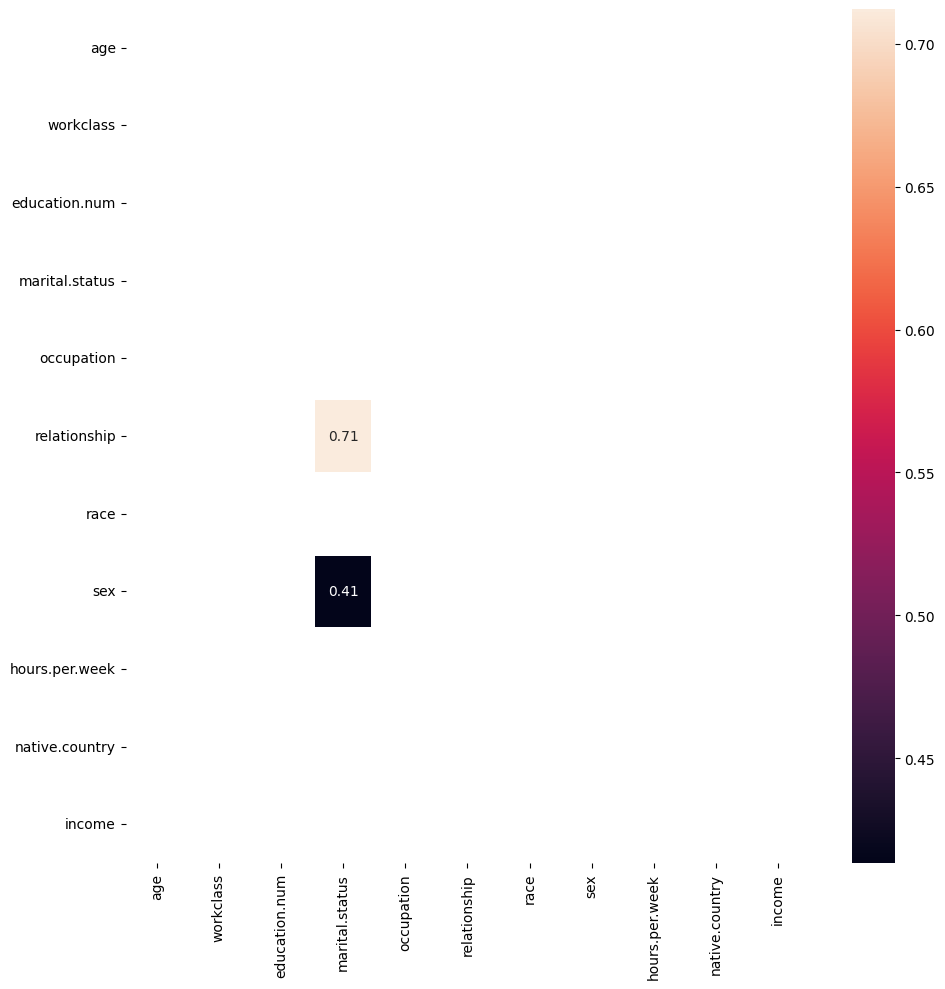

In [15]:
# Mapa correlación de df_facto de + del 0,4 para ver si tenemos alguna columna que también podamos eliminar.

corr = df_facto.corr()
high_correlation = corr[corr.abs() > 0.40]
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10,10))
sns.heatmap(high_correlation, annot=True, mask=mask, linewidths=3, fmt=".2f")

plt.tight_layout()
plt.show()

In [16]:
# Valoro que columna eliminar si 'relationship' o 'marital.status' por la información que me vierte.
df['marital.status'].value_counts()

marital.status
Married-civ-spouse       14059
Never-married             9711
Divorced                  4212
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64

In [17]:
# Elimino 'relationship' ya que la de marital me da más información.
df = df.drop(['relationship'], axis=1)

In [18]:
# Transformo nuestra variable de ingreso a 0 y  1

df['income'] = df['income'].str.strip()
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [19]:
# Realizo one-hot-encoding para pasar a numerico las variables categóricas.

categorical_cols = ['sex','workclass','marital.status', 'occupation', 'race', 'native.country']
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)

In [20]:
# Normalizacion de las variables numericas

scaler = StandardScaler()
df_encoded[['age', 'hours.per.week','education.num']] = scaler.fit_transform(df_encoded[['age', 'hours.per.week', 'education.num']])

In [21]:
# Compruebo que todo está en valores numéricos.

df_encoded.head()

,age,education.num,hours.per.week,income,sex_Female,sex_Male,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,3.317157,-0.440434,-1.914647,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,1.184832,-2.402221,-0.078031,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,0.194824,-0.048076,-0.078031,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
5,-0.338257,-0.440434,0.339381,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
6,-0.033639,-1.617506,-0.078031,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


## 3. Define el problema de recomendación. 
Plantea cómo vas a estructurar tu sistema de recomendación:

¿Qué se quiere recomendar?
> Que hacer para aumentar ingresos anuales, como: cambiar de ocupación, nivel educativo, aumentar horas de trabajo...

¿Cuál será el "usuario" en este caso?
> Usaré todo el data para que nos recomiende cuales serían las caracteristicas idoneas para ganar más anualmente.

¿Qué variables definen el perfil de un usuario?
> Pues edad, nivel de educación, trabajo, horas semanales, sexo, raza, pais....



## 4. Construye el sistema de recomendación. 
Usa uno de los siguientes enfoques:

Filtrado basado en contenido. Representa a cada usuario como un vector y calcula similitudes entre usuarios y recomendaciones.

Filtrado colaborativo. Simula una matriz de usuarios vs. trayectorias. Aplica k-NN, correlación de Pearson o matrix factorization.

Sistema híbrido. Combina ambos enfoques.

Pruebas con casos simulados. Construye perfiles simulados de usuarios hipotéticos y fijate qué trayectorias (educación, ocupación, etc.) les recomendaría el sistema para mejorar su ingreso estimado.

In [ ]:
# Split
x = df_encoded.drop(columns=['income'])
y = df_encoded['income']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=18)

f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}"

'Entrenamiento: (24111, 79), Prueba: (6028, 79)'

In [25]:
# Crear el modelo SVD
model = SVD()

# Entrenar el modelo con el conjunto de entrenamiento
model.fit(X_train)

AttributeError: 'DataFrame' object has no attribute 'n_users'